<a href="https://colab.research.google.com/github/seisbench/seisbench/blob/main/examples/04b_training_deepsubdas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hint:** To help with the high compute demand of DAS models, SeisBench integrates GPU support. For this tutorial, we strongly recommend to select a Colab runtime with GPU support. To enable GPU support, select *Runtime -> Change runtime type* from the menu.

![image](https://raw.githubusercontent.com/seisbench/seisbench/main/docs/_static/seisbench_logo_subtitle_outlined.svg)

*This code is necessary on colab to install SeisBench with DAS support. If SeisBench is already installed on your machine, you can skip this.*

In [ ]:
!pip install "seisbench[das]"

# Training DeepSubDAS

This tutorial introduces the SeisBench DAS data format and how to use it for training a model. We use the example of DeepSubDAS. Before going through this tutorial, it might be useful to have a look at the "Training PhaseNet" tutorial, where some of the fundamental concepts of SeisBench are introduced in more detail.

The tutorial is intended to highlight the basic principles of training DAS models. However, DAS data is huge and models for DAS are typically heavy. Therefore, to make it possible to run this tutorial on Colab or laptops with limited compute, we cut corners in some places. We point out where we do so.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.models import ResNet101_Weights

import seisbench.data as sbd
import seisbench.generate as sbg
import seisbench.models as sbm
from seisbench.util import worker_seeding

## SeisBench DAS datasets

For this tutorial, we use the MLSubDAS dataset, a collection of DAS records from submarine fibers. We first check, which chunks are available.

In [2]:
sbd.MLSubDAS.available_chunks()

['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']

To limit the amount of data, we will only use one chunk for this tutorial. For training a production grade model, all chunks should be used. Note that the constraint is the download time and the hard-disk space on Colab. SeisBench only loads the data in memory when it's needed for training and evicts it directly afterwards. This way, the memory footprint stays essentially constant.

**Hint: As the warning below points out, MLSubDAS is a semi-automatically annotated dataset. Most likely, you'll see some of the imperfections of the model in the examples during this tutorial.**

In [3]:
data = sbd.MLSubDAS(chunks=["00"])

2026-06-22 09:40:02,140 | seisbench | WARNING | This dataset has been annotated semi-automatically. The annotations will be incomplete and high picking errors (>1 s) or spatially incoherent labeling occurs. Check out the original publication for details on the dataset and annotation strategy. The limitations of this dataset should be taken into account when using it for training or evaluation.


Let's have a look at what a DAS dataset looks like in SeisBench. As for classical waveform datasets, the data is organized through a dataframe with metadata.

In [4]:
data.metadata

,record_identifier,record_sampling_rate_hz,record_p_labels,record_s_labels,split,record_channel_spacing_m,source_id,source_magnitude,source_magnitude_type,source_latitude_deg,source_longitude_deg,source_depth_km,source_origin_time,source_region,record_name,chunk
0,2023-06-10_EventID_11707158_KKFLS,100.0,4617,3742,train,9.57,11707158,2.4,ML,59.724,-152.662,81.4,2023-06-10 04:43:30.917,alaska,record_0,00
1,2023-06-10_EventID_11707158_TERRA,100.0,2892,4879,train,9.57,11707158,2.4,ML,59.724,-152.662,81.4,2023-06-10 04:43:30.917,alaska,record_1,00
2,2023-06-10_EventID_11707188_KKFLS,100.0,1574,4049,test,9.57,11707188,1.9,ML,59.262,-152.349,71.5,2023-06-10 07:33:00.219,alaska,record_2,00
3,2023-06-10_EventID_11707188_TERRA,100.0,0,3550,train,9.57,11707188,1.9,ML,59.262,-152.349,71.5,2023-06-10 07:33:00.219,alaska,record_3,00
4,2023-06-10_EventID_11707192_KKFLS,100.0,6497,4540,train,9.57,11707192,3.5,ML,60.702,-152.084,88.8,2023-06-10 08:44:56.996,alaska,record_4,00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2023-06-26_EventID_11713258_TERRA,100.0,1374,1273,train,9.57,11713258,2.5,ML,59.731,-151.716,48.9,2023-06-26 12:48:43.811,alaska,record_95,00
96,2023-06-27_EventID_11713626_KKFLS,100.0,0,1343,train,9.57,11713626,1.5,ML,59.287,-152.586,73.1,2023-06-27 02:25:35.321,alaska,record_96,00
97,2023-06-27_EventID_11713632_KKFLS,100.0,3787,2833,train,9.57,11713632,2.5,ML,60.027,-151.118,43.7,2023-06-27 02:44:45.752,alaska,record_97,00
98,2023-06-27_EventID_11713632_TERRA,100.0,1457,1239,train,9.57,11713632,2.5,ML,60.027,-151.118,43.7,2023-06-27 02:44:45.752,alaska,record_98,00


Each metadata row is associated to a DAS record and a set of annotations. This is different from the classical waveform dataset, where annotations are stored directly in the metadata. We can query a sample of metadata/record/annotations using `get_sample`.

In [5]:
metadata, record, annotations = data.get_sample(0)

The metadata for the sample is a simple dictionary.

In [6]:
metadata

{'record_identifier': '2023-06-10_EventID_11707158_KKFLS',
 'record_sampling_rate_hz': 100.0,
 'record_p_labels': 4617,
 'record_s_labels': 3742,
 'split': 'train',
 'record_channel_spacing_m': 9.57,
 'source_id': '11707158',
 'source_magnitude': 2.4,
 'source_magnitude_type': 'ML',
 'source_latitude_deg': 59.724,
 'source_longitude_deg': -152.662,
 'source_depth_km': 81.4,
 'source_origin_time': Timestamp('2023-06-10 04:43:30.917000'),
 'source_region': 'alaska',
 'record_name': 'record_0',
 'chunk': '00'}

The record itself is an array. Note that this array is currently a HDF5 dataset, i.e., a pointer to the data on hard disk. `get_sample` by default returns such a view of the dataset, because it avoids actually loading the data in memory. As often, only a small chunk of the data is actually of interest, it will be sufficient to load this part later.

In [7]:
record

<HDF5 dataset "record": shape (12000, 8531), type "<f4">

The annotations arre a dictionary, linking the name of an annotation to a list of samples where this annotation occurs. Note that this example has two S waves fronts that are labeled. Each individual annotation is an array of the same length as the number of channels in the data. Each entry lists at which sample (in time) this feature occurs in the record. NaN values are used for missing labels.

In [8]:
annotations

{'P_0': array([1064., 1064., 1064., ...,   nan,   nan,   nan], shape=(8531,)),
 'S_0': array([2217.5, 2217.5, 2217.5, ...,    nan,    nan,    nan], shape=(8531,)),
 'S_1': array([nan, nan, nan, ..., nan, nan, nan], shape=(8531,))}

As for classical waveform datasets, SeisBench DAS datasets typically come with recommended splits into training, development and test portion. They can be accessed the same way.

In [9]:
train, dev, test = data.train_dev_test()
print(data.metadata["split"].value_counts())

split
train    74
test     16
dev      10
Name: count, dtype: int64


## Training DeepSubDAS

Now it's time to train the model using the MLSubDAS data. To this end, we need to turn the data from the dataset into examples for the model. We do this using generator pipelines and augmentations.

As the first augmentation, we use a window selection. This augmentation cuts a window of predefined size from the (most likely) larger raw data. We select windows with 1000 samples and 500 channels. We also require, that the window contains at least one annotation. Note that every time the augmentation is called, it will randomly select a new subwindow from the data. Note that the window selection should always come first, as it will rewrite the annotations to fit the window. It will also load the data into memory.

*Hint: (1000, 500) is a rather small window size. We use it to ensure everything fits into GPU memory. Larger window sizes are typically advisable to give the model more context, which is particularly important to differentiate P from S waves.*

In [10]:
window = sbg.RandomDASWindow(
    shape=(1000, 500),
    contains_annotation=True,
)

Next, we use an augmentation to generate labels. We use probabilistic labels that write probability curves for P and S in each channel. The label will have the same shape as the data. You might notice the slightly convolved writing of `annotation_mapping`. This is simply stating that all "P_0", "P_1", ... should be mapped to "P" and the same for S waves. This is necessary, as the dataset might contain multiple P/S annotations for one record.

*Hint: We use boxcar labels and a fairly high sigma. Both are typically not optimal, because they are too broad and unspecific, but lead to fast model training in the beginning because they have a lot of probability mass. For a practical use case, triangle or Gaussian labels are better, because they have a unique peak at the actual arrival sample. However, it might be useful to first train a couple of epochs with boxcars and then change the label shape for the remainder of the training to accelerate convergence.*

In [11]:
labeller = sbg.ProbabilisticDASLabeller(
    annotation_mapping={
        **{f"P_{i}": "P" for i in range(100)},
        **{f"S_{i}": "S" for i in range(100)},
    },
    noise_map=True,
    label_shape="box",
    sigma=50,
)

Now we just have to put the augmentations together. We create two generators. One for the training subset and one for the development subset. In this tutorial, we ignore the test subset, which should be used for the final model validation, once all hyperparameters have been settled on.

In [12]:
train_generator = sbg.DASGenerator(train)
train_generator.augmentation(window)
train_generator.augmentation(labeller)

dev_generator = sbg.DASGenerator(dev)
dev_generator.augmentation(window)
dev_generator.augmentation(labeller)

Let's visualize a few examples. Every time you run this cell, a random trace is selected from the data and a random subset is cut out. The four panels show the data, the P wave, the S wave and the noise. If you click through a few examples, you'll quickly spot imperfections in the labelling as discussed above.

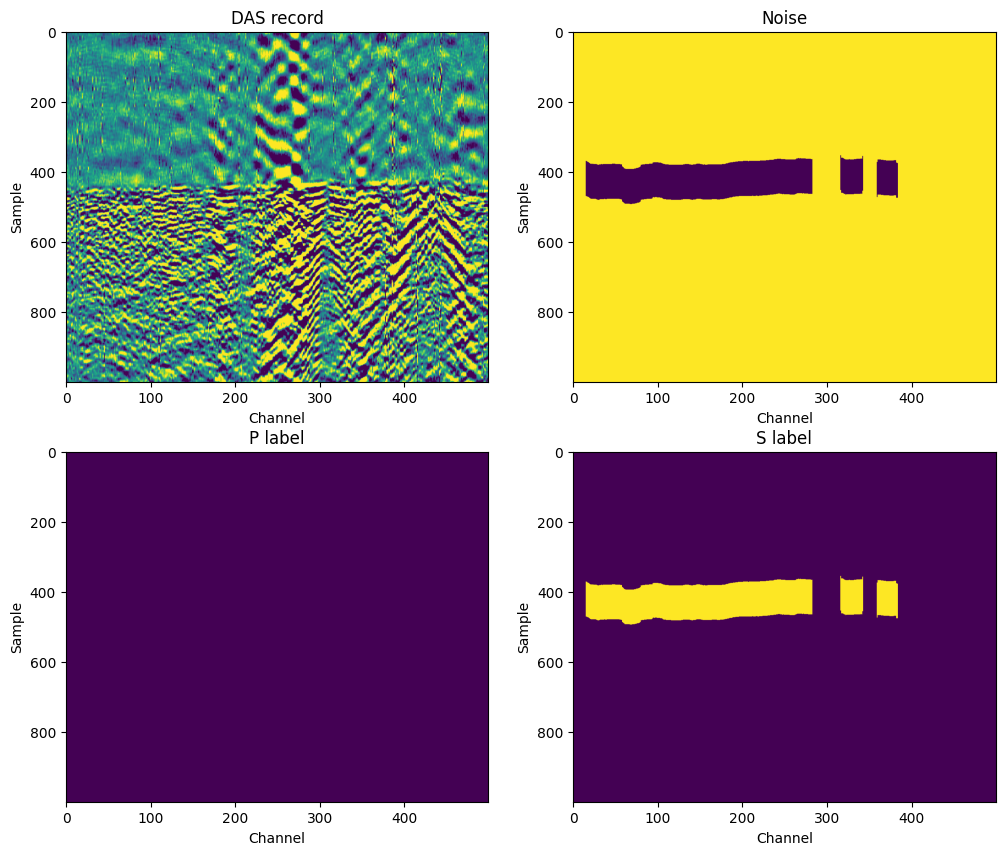

In [26]:
sample = train_generator[np.random.randint(len(train_generator))]

fig = plt.figure(figsize=(12, 10))
axs = fig.subplots(2, 2)
axs[0, 0].imshow(
    sample["X"],
    vmin=np.quantile(sample["X"], 0.1),
    vmax=np.quantile(sample["X"], 0.9),
    aspect="auto",
)
axs[0, 1].imshow(sample["y"][2], vmin=0, vmax=1, aspect="auto")
axs[1, 0].imshow(sample["y"][0], vmin=0, vmax=1, aspect="auto")
axs[1, 1].imshow(sample["y"][1], vmin=0, vmax=1, aspect="auto")

axs[0, 0].set_title("DAS record")
axs[0, 1].set_title("Noise")
axs[1, 0].set_title("P label")
axs[1, 1].set_title("S label")

for ax in axs.reshape(-1):
    ax.set_xlabel("Channel")
    ax.set_ylabel("Sample")

Let's create the actual model. We use a DeepSubDAS model from SeisBench. As for the other SeisBench models, the model is a standard Pytorch model with some additional functionality. For training, we will use this Pytorch interface.

DeepSubDAS builds on the deeplab architecture. As for many large models, it is often beneficial to start from a pretrained model, even if it's from a very different task, rather than using a random model initialization. Here, we use such weights for the deeplab backbone.

In [14]:
model = sbm.DeepSubDAS(deeplab_weights_backbone=ResNet101_Weights.IMAGENET1K_V1)

As DAS models are typically heavy, we move the model to an accelerator, typically a GPU. In principle, it is possible to run this notebook on CPU, it will just be very slow.

In [15]:
model.to_preferred_device(verbose=True)

Model device: cuda:0


Below, we configure the data loaders for the training. They are simple wrappers around the data generators. If you encounter out-of-memory errors when training the model, reduce the batch size. Note that due to the batch normalization layers, the batch size needs to be at least 2.

*Hint: For larger model training, it might be useful to use a multi-GPU setup with higher batch size.*

In [16]:
batch_size = 8  # Might need to be decreased if you get an out-of-memory error
num_workers = 4  # The number of threads used for loading data

train_loader = DataLoader(
    train_generator,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    worker_init_fn=worker_seeding,
)

dev_loader = DataLoader(
    dev_generator,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=worker_seeding,
)

Next, we configure the optimizer and the loss function. For the loss function, we use a classical cross-entropy loss. For optimizing, we use the Adam optimizer.

*Hint: We only use 4 training epochs to accelerate the training. The model will not be fully trained after these epochs. Typically models are trained for much longer, often more than 100 epochs.*

In [17]:
learning_rate = 1e-3
epochs = 4

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


def fuzzy_cross_entropy_loss(logits, target_probs, reduction="batchmean"):
    log_probs = F.log_softmax(logits, dim=1)
    loss = (-target_probs * log_probs).sum(dim=1)
    loss = loss.mean()
    return loss


loss_fn = fuzzy_cross_entropy_loss

Lastly, we define the training and test loops. In both we simply apply the model and calculate the loss function. In the training loop, we furthermore run a backward step to estimate the gradient of the parameters and then adjust the parameters to reduce the loss.

In [18]:
def train_loop(dataloader):
    size = len(dataloader.dataset)
    for batch_id, batch in enumerate(dataloader):
        # Compute prediction and loss
        x = batch["X"].to(model.device)
        pred = model(x)
        loss = loss_fn(pred["full"], batch["y"].to(model.device))

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_id % 1 == 0:
            loss, current = loss.item(), batch_id * batch["X"].shape[0]
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader):
    num_batches = len(dataloader)
    test_loss = 0

    model.eval()  # close the model for evaluation

    with torch.no_grad():
        for batch in dataloader:
            x = batch["X"].to(model.device)
            pred = model(x)
            test_loss += loss_fn(pred["full"], batch["y"].to(model.device)).item()

    model.train()  # re-open model for training stage

    test_loss /= num_batches
    print(f"Test avg loss: {test_loss:>8f} \n")

Let's train the model. Depending on your hardware, this might take a couple of minutes (or even longer). Each training batch and after each epoch the current loss is printed. Note that the loss might occasionally increase between steps because it depends on the randomness of the samples.

In [19]:
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_loop(train_loader)
    test_loop(dev_loader)

Epoch 1
-------------------------------
loss: 1.046698  [    0/   74]
loss: 1.004746  [    8/   74]
loss: 0.987844  [   16/   74]
loss: 0.899000  [   24/   74]
loss: 0.834896  [   32/   74]
loss: 0.802396  [   40/   74]
loss: 0.774347  [   48/   74]
loss: 0.741700  [   56/   74]
loss: 0.728771  [   64/   74]
loss: 0.701016  [   18/   74]
Test avg loss: 1.486155 

Epoch 2
-------------------------------
loss: 0.689677  [    0/   74]
loss: 0.671656  [    8/   74]
loss: 0.663174  [   16/   74]
loss: 0.647954  [   24/   74]
loss: 0.661119  [   32/   74]
loss: 0.638093  [   40/   74]
loss: 0.636432  [   48/   74]
loss: 0.661963  [   56/   74]
loss: 0.626118  [   64/   74]
loss: 0.618432  [   18/   74]
Test avg loss: 1.485240 

Epoch 3
-------------------------------
loss: 0.619364  [    0/   74]
loss: 0.625028  [    8/   74]
loss: 0.622535  [   16/   74]
loss: 0.627200  [   24/   74]
loss: 0.619576  [   32/   74]
loss: 0.645834  [   40/   74]
loss: 0.608764  [   48/   74]
loss: 0.623227  [ 

Once the model is fully trained, we can apply it to some example from the development data. The plots are the same as for the examples above, just that we've now added an extra row for the predictions. Run the cell a few times and inspect the examples. Most likely, you will see that the model already does a decent job for S waves. Sometimes it is even able to produce better S labels than in the original data. However, P waves are barely detected. This is partially due to a lower number of P labels in the data, but also partially due to the characteristics of DAS data. Distinguishing P and S waves on the 1C data is challenging and the best cue is their sequencing. However, with the small window size used in this example notebook, few windows will contain both P and S waves.

Text(0.5, 1.0, 'S prediction')

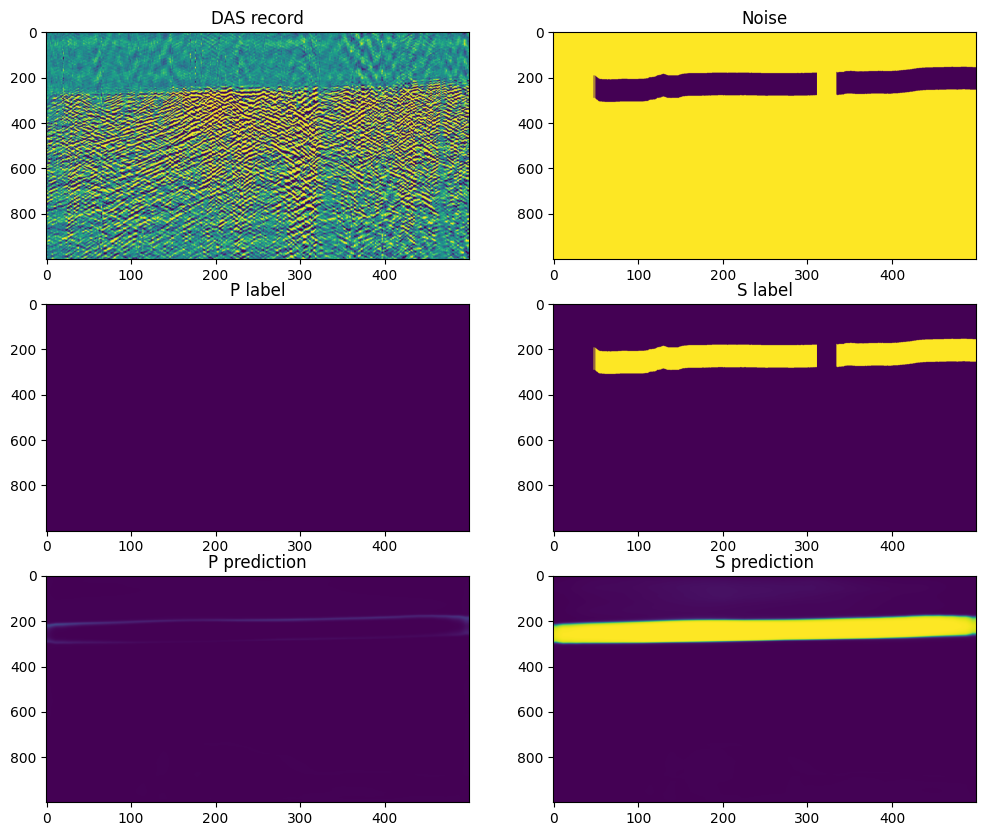

In [20]:
sample = dev_generator[np.random.randint(len(dev_generator))]

fig = plt.figure(figsize=(12, 10))
axs = fig.subplots(3, 2)
axs[0, 0].imshow(
    sample["X"],
    vmin=np.quantile(sample["X"], 0.1),
    vmax=np.quantile(sample["X"], 0.9),
    aspect="auto",
)
axs[0, 1].imshow(sample["y"][2], vmin=0, vmax=1, aspect="auto")
axs[1, 0].imshow(sample["y"][0], vmin=0, vmax=1, aspect="auto")
axs[1, 1].imshow(sample["y"][1], vmin=0, vmax=1, aspect="auto")

model.eval()
with torch.no_grad():
    x = torch.tensor(sample["X"]).to(model.device).unsqueeze(0)
    pred = model(x)
    axs[2, 0].imshow(pred["full"][0, 0].cpu(), vmin=0, vmax=1, aspect="auto")
    axs[2, 1].imshow(pred["full"][0, 1].cpu(), vmin=0, vmax=1, aspect="auto")
model.train()

axs[0, 0].set_title("DAS record")
axs[0, 1].set_title("Noise")
axs[1, 0].set_title("P label")
axs[1, 1].set_title("S label")
axs[2, 0].set_title("P prediction")
axs[2, 1].set_title("S prediction")

This concludes the tutorial on training a DAS model with SeisBench. As indicated, this notebook is a minimal example for a training workflow intended for instruction. For training a production-grade model, this workflow should be adjusted. In addition to the recommendations above, a few things should be taken into account:

- For training models, it's often useful to build on existing frameworks for structuring training, for example, [Pytorch Lightning](https://github.com/Lightning-AI/pytorch-lightning). Such frameworks come with useful functionality, such as multi-GPU training, integration with loggers, configuration management, ... . Alternatively, you can use individual tools for each of these aspects, such as [tensorboard](https://www.tensorflow.org/tensorboard) or [hydra](https://github.com/facebookresearch/hydra).
- Labeled data for DAS is still rare. This makes data augmentation, such as adding noise or flipping input traces even more important. For a high-end model, you might consider such augmentations.
- In this example, we completely ignored aspects such as channel spacing and data sampling rate. This is because the MLSubDAS dataset has consistent sampling rate and the channel spacings are similar across all examples (check metadata for details). However, when training a model on different data, you should take into account how to choose these parameters.